In [8]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

**API call to get all Published Datasets**

In [9]:
api_url_base = 'https://api.cellxgene.cziscience.com'
path_segment = '/datasets'
url = f'{api_url_base}/curation/v1{path_segment}'
r = requests.get(url)
datasets = r.json()

**Extract necessary information, assign publication based on the earliest published date for each Collection**

In [10]:
datasets_df = pd.DataFrame(datasets)[['collection_id','primary_cell_count','published_at']]
datasets_df['published_at'] = pd.to_datetime(datasets_df['published_at']).dt.tz_localize(None)

collection_earliest = (
    datasets_df
    .groupby('collection_id')['published_at']
    .min()
    .reset_index()
    .rename(columns={'published_at': 'earliest_date'})
)

result = (
    datasets_df
    .merge(collection_earliest, on='collection_id')
    .groupby('earliest_date')
    .agg(
        collections=('collection_id', 'nunique'),
        primary_cells=('primary_cell_count', 'sum')
    )
    .reset_index()
)
result

,earliest_date,collections,primary_cells
0,2020-08-26 23:15:51,1,581777
1,2020-08-26 23:15:53,1,130626
2,2020-08-26 23:15:54,1,77650
3,2020-08-26 23:15:58,1,75071
4,2020-09-28 16:50:57,1,599926
...,...,...,...
364,2026-04-24 21:46:20,1,125886
365,2026-04-29 21:10:48,1,95728
366,2026-04-30 16:39:24,1,117308
367,2026-04-30 17:25:28,1,4502568


**Extract citation stats for the CELLxGENE Discover publication**\
**Export CSV from [Dimensions](https://app.dimensions.ai/discover/publication?or_subset_publication_citations=pub.1182803254)**

In [11]:
dimensions_export = 'Dimensions-Publication-2026-05-01_18-29-40.csv.zip'

cited_by = (
    pd.read_csv(dimensions_export, skiprows=1)[['Publication date']]
    .assign(**{
        'Publication date': lambda x: x['Publication date'].apply(
            lambda d: f"{d}-01" if isinstance(d, str) and len(d) == 7 else d
        )
    })
)
cited_by['Publication date'] = pd.to_datetime(cited_by['Publication date']).dt.tz_localize(None)
cited_by = (
    cited_by['Publication date']
    .value_counts()
    .reset_index()
    .rename(columns={'Publication date': 'earliest_date', 'count': 'cited_by'})
)
cited_by

,earliest_date,cited_by
0,2025-11-26,5
1,2026-01-09,4
2,2025-12-01,4
3,2025-06-04,4
4,2025-11-10,4
...,...,...
259,2025-09-30,1
260,2025-09-25,1
261,2025-09-24,1
262,2025-09-21,1


**Calculate the relative date and running totals**

In [12]:
result = (
    result
    .merge(cited_by, on='earliest_date', how='outer')
    .fillna(0)
    .sort_values('earliest_date')
    .reset_index(drop=True)
)

for col in ['collections', 'primary_cells', 'cited_by']:
    result[f'cumsum_{col}'] = result[col].cumsum().astype('Int64')

result

,earliest_date,collections,primary_cells,cited_by,cumsum_collections,cumsum_primary_cells,cumsum_cited_by
0,2020-08-26 23:15:51,1.0,581777.0,0.0,1,581777,0
1,2020-08-26 23:15:53,1.0,130626.0,0.0,2,712403,0
2,2020-08-26 23:15:54,1.0,77650.0,0.0,3,790053,0
3,2020-08-26 23:15:58,1.0,75071.0,0.0,4,865124,0
4,2020-09-28 16:50:57,1.0,599926.0,0.0,5,1465050,0
...,...,...,...,...,...,...,...
628,2026-04-24 21:46:20,1.0,125886.0,0.0,365,150049875,374
629,2026-04-29 21:10:48,1.0,95728.0,0.0,366,150145603,374
630,2026-04-30 16:39:24,1.0,117308.0,0.0,367,150262911,374
631,2026-04-30 17:25:28,1.0,4502568.0,0.0,368,154765479,374


**View the current counts**

In [13]:
print(f"{result['cumsum_primary_cells'].max():>12,} Cells")
print(f"{result['cumsum_collections'].max():>12,} Collections")
print(f"{result['cumsum_cited_by'].max():>12,} Cited Bys")

 154,922,772 Cells
         369 Collections
         374 Cited Bys


**Plot a) the Collection & Primary Cell Count growth and b) Publications citing the CELLxGENE resource publication**

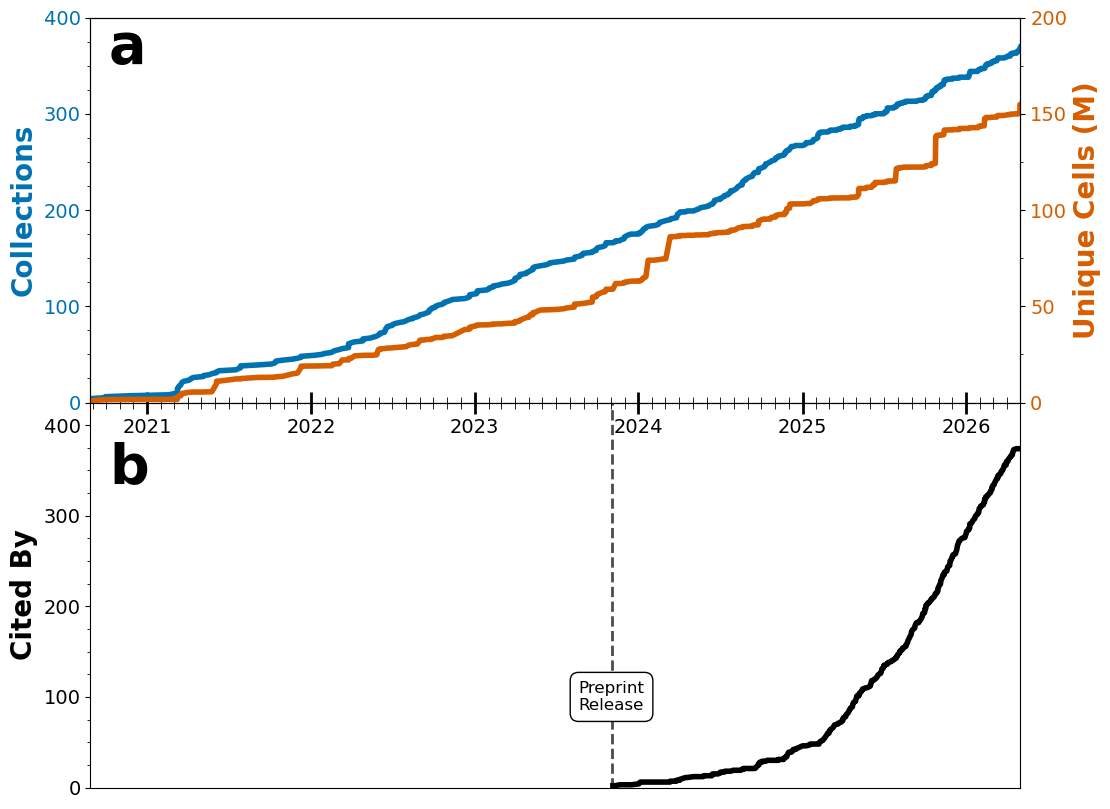

In [14]:
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0},
                                sharex=True)

coll_color = (0/255, 114/255, 178/255)
cell_color = (213/255, 94/255, 000/255)
cite_color = 'black'

preprint_release = pd.Timestamp('2023-11-02')
cited_by_filtered = result[result['earliest_date'] >= preprint_release]

def setup_y(ax, x, y, label, color, lim, del_mj, del_mi):
    ax.set_ylabel(label, color=color, fontsize=20, fontweight='bold')
    ax.set_ylim(0, lim)
    ax.set_yticks(np.arange(0, lim + 0.1, del_mj), minor=False)
    ax.set_yticks(np.arange(0, lim + 0.1, del_mi), minor=True)
    ax.tick_params(axis='y', labelcolor=color, labelsize=14)
    ax.plot(x, y, color=color, linewidth=4)

# a: left y-axis (collections)
setup_y(ax1, result['earliest_date'], result['cumsum_collections'],
        'Collections', coll_color, 400, 100, 25)

# a: right y-axis (cells)
ax2 = ax1.twinx()
setup_y(ax2, result['earliest_date'], result['cumsum_primary_cells'] / 1_000_000,
        'Unique Cells (M)', cell_color, 200, 50, 25)

# b: left y-axis (cited by)
setup_y(ax3, cited_by_filtered['earliest_date'], cited_by_filtered['cumsum_cited_by'],
        'Cited By', cite_color, 425, 100, 25)

# shared: x-axis
ax1.set_xlim(result['earliest_date'].min(), result['earliest_date'].max())
ax1.xaxis.set_minor_locator(mdates.MonthLocator())


ax1.tick_params(axis='x', which='major', labelsize=14, length=8, width=2, pad=-25, direction='in')
ax1.tick_params(axis='x', which='minor', length=4, direction='in')


ax3.tick_params(axis='x', which='major', labelsize=14, length=8, width=2, pad=-25,
               labeltop=True, labelbottom=False, top=True, bottom=False, direction='in')
ax3.tick_params(axis='x', which='minor', length=4, top=True, bottom=False, direction='in')

# b: vertical line for preprint release date
ax3.axvline(preprint_release, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax3.text(preprint_release, 100, 'Preprint\nRelease', 
         ha='center', va='center', fontsize=12, color='black',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=1))

# Add labels a and b
ax1.text(0.02, 0.99, 'a', transform=ax1.transAxes, 
         fontsize=40, fontweight='bold', va='top', ha='left')
ax3.text(0.02, 0.9, 'b', transform=ax3.transAxes, 
         fontsize=40, fontweight='bold', va='top', ha='left')

plt.savefig('cxg_growth.png', dpi=300, bbox_inches='tight')
plt.show()